In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [4]:
DATA_PATH = "/home/netsec1/Kathan/MaleVis 2 dataset/malevis_train_val_300x300/train"

transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = ImageFolder(DATA_PATH, transform=transform)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4
)

print("Total images:", len(dataset))


Total images: 9947


In [5]:
class FeatureReduce(nn.Module):
    def __init__(self, final_dim, dropout=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=2, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv2d(8, 16, 3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 224, 3, stride=2, padding=1),
            nn.BatchNorm2d(224),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc_expand = nn.Linear(224, final_dim * 2)
        self.fc_project = nn.Linear(final_dim * 2, final_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc_expand(x))
        return self.fc_project(x)


In [6]:
LATENT_DIM = 10  # Malevis setting

model = FeatureReduce(final_dim=LATENT_DIM).to(device)

# 🔴 IMPORTANT: load your trained checkpoint
model.load_state_dict(
    torch.load("exp-4_1_3.pth", map_location=device),
    strict=False
)

model.eval()


FeatureReduce(
  (conv): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.1, inplace=False)
    (16): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (17)

In [7]:
all_features = []

with torch.no_grad():
    for x, _ in loader:
        x = x.to(device)
        z = model(x)
        z = torch.tanh(z)      # match forward()
        all_features.append(z.cpu())

Z = torch.cat(all_features, dim=0).numpy()

print("Latent feature matrix shape:", Z.shape)


Latent feature matrix shape: (9947, 10)


In [8]:
pca = PCA()
pca.fit(Z)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("\nExplained variance per component:")
for i, v in enumerate(explained):
    print(f"Dim {i+1}: {v:.4f}")

print("\nCumulative explained variance:")
for i, v in enumerate(cumulative):
    print(f"Up to Dim {i+1}: {v:.4f}")



Explained variance per component:
Dim 1: 0.7961
Dim 2: 0.1525
Dim 3: 0.0262
Dim 4: 0.0152
Dim 5: 0.0055
Dim 6: 0.0032
Dim 7: 0.0012
Dim 8: 0.0000
Dim 9: 0.0000
Dim 10: 0.0000

Cumulative explained variance:
Up to Dim 1: 0.7961
Up to Dim 2: 0.9486
Up to Dim 3: 0.9749
Up to Dim 4: 0.9901
Up to Dim 5: 0.9956
Up to Dim 6: 0.9988
Up to Dim 7: 1.0000
Up to Dim 8: 1.0000
Up to Dim 9: 1.0000
Up to Dim 10: 1.0000


In [9]:
threshold_90 = 0.90
threshold_95 = 0.95

d_eff_90 = np.argmax(cumulative >= threshold_90) + 1
d_eff_95 = np.argmax(cumulative >= threshold_95) + 1

print(f"\nEffective latent dim (90% variance): {d_eff_90}")
print(f"Effective latent dim (95% variance): {d_eff_95}")



Effective latent dim (90% variance): 2
Effective latent dim (95% variance): 3


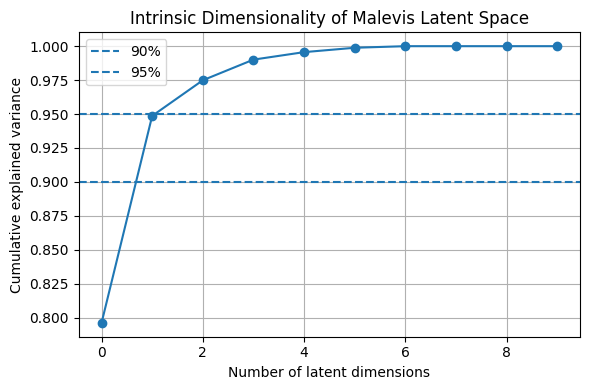

In [10]:
plt.figure(figsize=(6,4))
plt.plot(cumulative, marker='o')
plt.axhline(0.90, linestyle='--', label='90%')
plt.axhline(0.95, linestyle='--', label='95%')
plt.xlabel("Number of latent dimensions")
plt.ylabel("Cumulative explained variance")
plt.title("Intrinsic Dimensionality of Malevis Latent Space")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
'''
FFT method

'''

'\nFFT method\n\n'

In [12]:
import numpy as np
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from numpy.fft import fft2, fftshift


In [13]:
DATA_PATH = "/home/netsec1/Kathan/MaleVis 2 dataset/malevis_train_val_300x300/train"

transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = ImageFolder(DATA_PATH, transform=transform)

loader = DataLoader(
    dataset,
    batch_size=1,     # FFT per image
    shuffle=True
)

print("Total Malevis images:", len(dataset))


Total Malevis images: 9947


In [14]:
def compute_fft_energy(img_tensor):
    """
    img_tensor: shape (B, C, H, W)
    Returns:
        low_freq_ratio
        fft_magnitude
    """
    # Remove batch & channel dims
    img = img_tensor.squeeze().numpy()  # (H, W)

    if img.ndim != 2:
        raise ValueError(f"Expected 2D image, got {img.shape}")

    # FFT
    fft_img = fftshift(fft2(img))
    magnitude = np.abs(fft_img)
    energy = magnitude ** 2

    total_energy = energy.sum()

    # Low-frequency region
    h, w = energy.shape
    ch, cw = h // 2, w // 2
    radius = min(h, w) // 8   # same definition as Malimg

    low_energy = energy[
        ch - radius : ch + radius,
        cw - radius : cw + radius
    ].sum()

    low_freq_ratio = low_energy / total_energy
    return low_freq_ratio, magnitude


In [15]:
low_freq_ratios = []
fft_samples = []

NUM_IMAGES = 500   # enough for statistics

for i, (x, _) in enumerate(loader):
    if i >= NUM_IMAGES:
        break

    ratio, mag = compute_fft_energy(x)
    low_freq_ratios.append(ratio)

    if i < 5:
        fft_samples.append(mag)

low_freq_ratios = np.array(low_freq_ratios)


In [16]:
print("\nFFT Low-Frequency Energy Analysis (Malevis)")
print(f"Mean low-frequency energy ratio : {low_freq_ratios.mean():.4f}")
print(f"Std deviation                  : {low_freq_ratios.std():.4f}")
print(f"Min                             : {low_freq_ratios.min():.4f}")
print(f"Max                             : {low_freq_ratios.max():.4f}")



FFT Low-Frequency Energy Analysis (Malevis)
Mean low-frequency energy ratio : 0.9523
Std deviation                  : 0.0296
Min                             : 0.7986
Max                             : 0.9980


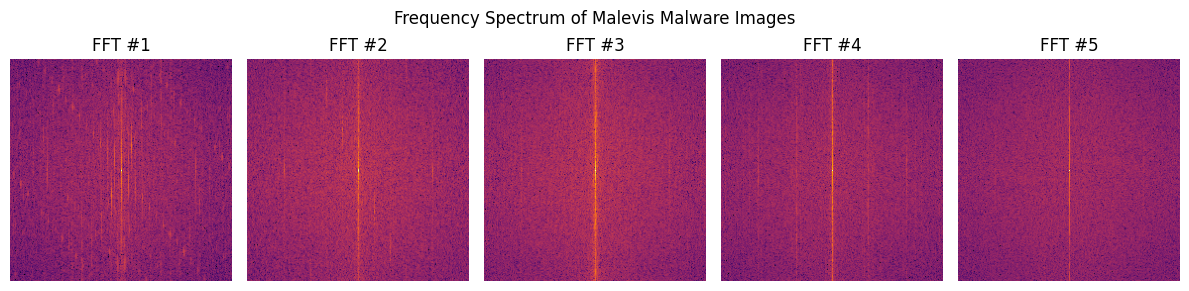

In [17]:
plt.figure(figsize=(12, 3))

for i, mag in enumerate(fft_samples):
    plt.subplot(1, len(fft_samples), i+1)
    plt.imshow(np.log(mag + 1e-8), cmap="inferno")
    plt.axis("off")
    plt.title(f"FFT #{i+1}")

plt.suptitle("Frequency Spectrum of Malevis Malware Images")
plt.tight_layout()
plt.show()


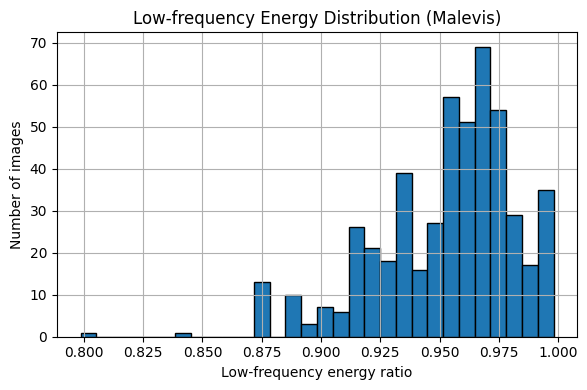

In [18]:
plt.figure(figsize=(6,4))
plt.hist(low_freq_ratios, bins=30, edgecolor="black")
plt.xlabel("Low-frequency energy ratio")
plt.ylabel("Number of images")
plt.title("Low-frequency Energy Distribution (Malevis)")
plt.grid(True)
plt.tight_layout()
plt.show()


Using device: cuda
Total images: 9947
Latent feature matrix shape: (9947, 10)

Explained variance per component (PGD-attacked):
Dim 1: 0.6738
Dim 2: 0.1458
Dim 3: 0.0629
Dim 4: 0.0451
Dim 5: 0.0340
Dim 6: 0.0169
Dim 7: 0.0108
Dim 8: 0.0086
Dim 9: 0.0021
Dim 10: 0.0000

Cumulative explained variance:
Up to Dim 1: 0.6738
Up to Dim 2: 0.8196
Up to Dim 3: 0.8825
Up to Dim 4: 0.9277
Up to Dim 5: 0.9616
Up to Dim 6: 0.9785
Up to Dim 7: 0.9893
Up to Dim 8: 0.9979
Up to Dim 9: 1.0000
Up to Dim 10: 1.0000


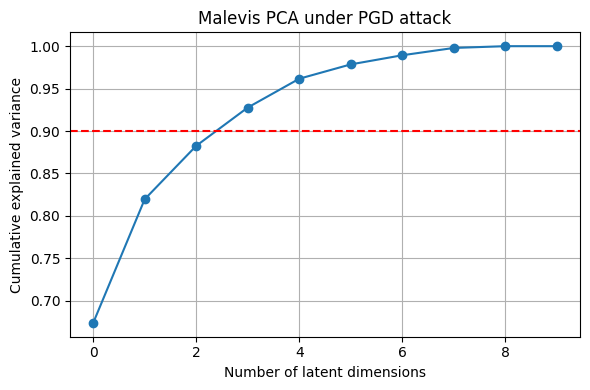

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# =========================
# Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# Dataset
# =========================
DATA_PATH = "/home/netsec1/Kathan/MaleVis 2 dataset/malevis_train_val_300x300/train"

transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = ImageFolder(DATA_PATH, transform=transform)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4
)

print("Total images:", len(dataset))

# =========================
# Feature extractor (same as clean PCA)
# =========================
class FeatureReduce(nn.Module):
    def __init__(self, final_dim, dropout=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=2, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv2d(8, 16, 3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 224, 3, stride=2, padding=1),
            nn.BatchNorm2d(224),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc_expand = nn.Linear(224, final_dim * 2)
        self.fc_project = nn.Linear(final_dim * 2, final_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc_expand(x))
        return self.fc_project(x)

# =========================
# PGD attack (input-level)
# =========================
def pgd_attack(model, images, eps=0.1, alpha=0.01, iters=7):
    images_orig = images.clone().detach()
    images_adv = images_orig + torch.empty_like(images_orig).uniform_(-eps, eps)
    images_adv = torch.clamp(images_adv, -1.0, 1.0)

    for _ in range(iters):
        images_adv.requires_grad_(True)
        features = model(images_adv)
        loss = features.norm(dim=1).mean()   # feature-space objective

        model.zero_grad()
        loss.backward()

        images_adv = images_adv + alpha * images_adv.grad.sign()
        delta = torch.clamp(images_adv - images_orig, -eps, eps)
        images_adv = torch.clamp(images_orig + delta, -1.0, 1.0).detach()

    return images_adv

# =========================
# Load trained encoder
# =========================
LATENT_DIM = 10  # Malevis

model = FeatureReduce(final_dim=LATENT_DIM).to(device)

# IMPORTANT: trained checkpoint
model.load_state_dict(
    torch.load("exp-4_1_3.pth", map_location=device),
    strict=False
)

model.eval()

# =========================
# Extract latent features under PGD
# =========================
all_features = []

for x, _ in loader:
    x = x.to(device)

    # PGD needs gradients
    x_adv = pgd_attack(
        model,
        x,
        eps=0.3,
        alpha=0.01,
        iters=7
    )

    # Feature extraction does not
    with torch.no_grad():
        z = model(x_adv)
        z = torch.tanh(z)   # match training forward
        all_features.append(z.cpu())

Z = torch.cat(all_features, dim=0).numpy()
print("Latent feature matrix shape:", Z.shape)

# =========================
# PCA
# =========================
pca = PCA()
pca.fit(Z)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("\nExplained variance per component (PGD-attacked):")
for i, v in enumerate(explained):
    print(f"Dim {i+1}: {v:.4f}")

print("\nCumulative explained variance:")
for i, v in enumerate(cumulative):
    print(f"Up to Dim {i+1}: {v:.4f}")

# =========================
# Optional: plot
# =========================
plt.figure(figsize=(6,4))
plt.plot(cumulative, marker='o')
plt.axhline(0.90, linestyle='--', color='red')
plt.xlabel("Number of latent dimensions")
plt.ylabel("Cumulative explained variance")
plt.title("Malevis PCA under PGD attack")
plt.grid(True)
plt.tight_layout()
plt.show()
